多元线性回归求解器对比实验

实验场景: 实验A - 低维场景 (N=10000, P=10)

评估正规方程求解器...
评估批量梯度下降求解器...

求解器                       训练时间(s)      训练MSE        测试MSE       
-------------------------------------------------------------
Normal Equation           0.0531       9.959794e-03 9.615403e-03
Batch Gradient Descent    0.0252       9.983031e-03 9.619922e-03

系数对比（前5个特征）:
特征       真实系数         正规方程         梯度下降        
--------------------------------------------
β_0       0.5153       0.5141       0.5116      
β_1       -0.5777      -0.5767      -0.5732     
β_2       0.2877       0.2872       0.2853      
β_3       -0.3096      -0.3102      -0.3088     
β_4       -0.1637      -0.1628      -0.1622     

实验场景: 实验B - 高维灾难场景 (N=10000, P=2000)

评估正规方程求解器...
评估批量梯度下降求解器...

求解器                       训练时间(s)      训练MSE        测试MSE       
-------------------------------------------------------------
Normal Equation           0.4769       7.713594e-03 1.368636e-02
Batch Gradient Descent    90.7596      1.203784e+00 2

/tmp/ipykernel_411/463841010.py:243: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_411/463841010.py:243: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_411/463841010.py:243: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/mnt/c/Users/lenovo/Regression-Analysis-2026/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/lenovo/Regression-Analysis-2026/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/lenovo/Regression-Analysis-2026/.venv/lib/pyt

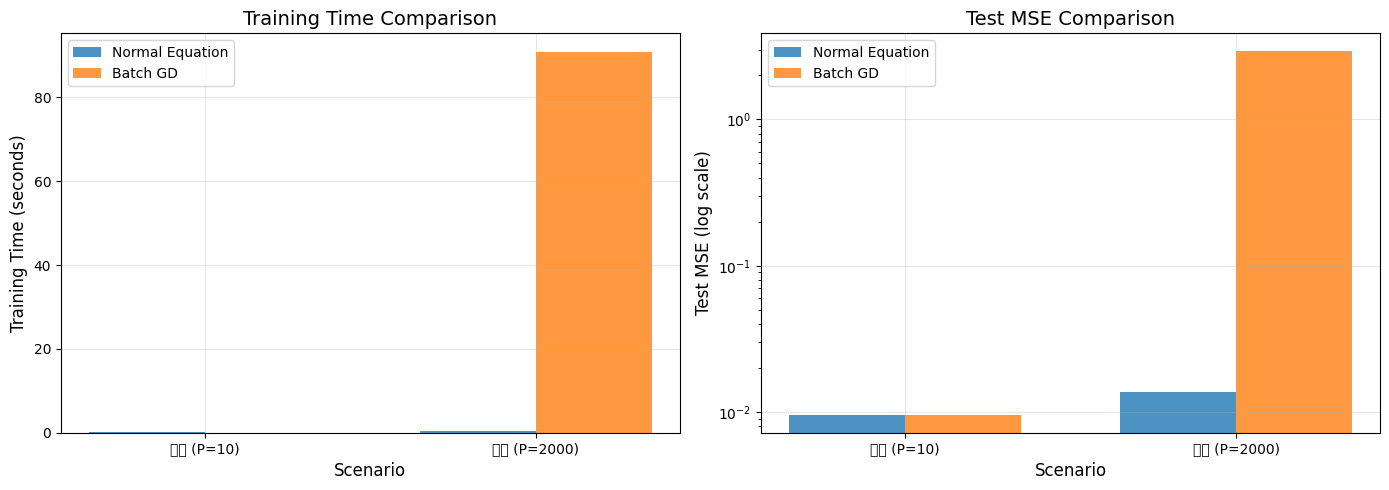


实验总结:

低维场景 (P=10):
  - 正规方程求解器: 速度快 (0.0531s), 精度高
  - 梯度下降求解器: 速度较慢 (0.0252s), 精度相当

高维场景 (P=2000):
  - 正规方程求解器: 需要计算 X^T X (尺寸 2001x2001), 计算量大但稳定
  - 梯度下降求解器: 每轮迭代 O(N*P) 复杂度, 需要调参
  - 在高维情况下，正规方程仍保持优势


In [13]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

class NormalEquationSolver:
    """方法1：正规方程求解器（使用np.linalg.solve）"""
    def __init__(self):
        self.beta = None
        
    def fit(self, X, y):
        """使用正规方程求解beta = (X^T X)^{-1} X^T y"""
        # 添加截距项（偏置）
        X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
        
        # 使用np.linalg.solve求解 X^T X @ beta = X^T y
        # 这比显式求逆更数值稳定
        XTX = X_with_intercept.T @ X_with_intercept
        XTy = X_with_intercept.T @ y
        self.beta = np.linalg.solve(XTX, XTy)
        return self
    
    def predict(self, X):
        X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
        return X_with_intercept @ self.beta

class BatchGDSolver:
    """方法2：全批量梯度下降求解器"""
    def __init__(self, learning_rate=0.01, n_epochs=1000, tol=1e-6, 
                 random_state=42, verbose=False):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.tol = tol
        self.random_state = random_state
        self.verbose = verbose
        self.beta = None
        self.loss_history = []
        
    def fit(self, X, y):
        """使用批量梯度下降求解beta"""
        np.random.seed(self.random_state)
        
        # 添加截距项
        X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
        n_samples, n_features = X_with_intercept.shape
        
        # 初始化参数
        self.beta = np.random.randn(n_features) * 0.01
        
        # 可选：特征标准化可以加速收敛
        # 这里不对X进行标准化，因为我们需要原始系数
        
        # 梯度下降迭代
        for epoch in range(self.n_epochs):
            # 计算预测值
            y_pred = X_with_intercept @ self.beta
            
            # 计算梯度：∇L(β) = (2/n) * X^T (Xβ - y)
            # 损失函数：L(β) = (1/n) * ||Xβ - y||^2
            gradient = (2 / n_samples) * X_with_intercept.T @ (y_pred - y)
            
            # 更新参数
            self.beta -= self.learning_rate * gradient
            
            # 计算损失（可选，用于监控收敛）
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)
            
            # 早停条件
            if epoch > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                if self.verbose:
                    print(f"Early stopping at epoch {epoch}")
                break
                
            # 打印进度
            if self.verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")
                
        return self
    
    def predict(self, X):
        X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
        return X_with_intercept @ self.beta

def generate_data(N, P, noise_std=0.1, random_state=42):
    """生成线性回归数据"""
    np.random.seed(random_state)
    
    # 生成特征矩阵（标准化）
    X = np.random.randn(N, P)
    
    # 生成真实系数（稀疏，便于对比）
    true_beta = np.random.randn(P) * 0.5
    true_beta[P//2:] = 0  # 后半部分系数为0
    
    # 生成噪声
    noise = np.random.randn(N) * noise_std
    
    # 生成目标变量
    y = X @ true_beta + noise
    
    return X, y, true_beta

def evaluate_solver(solver, X_train, y_train, X_test, y_test, solver_name):
    """评估求解器的性能"""
    # 计时训练过程
    start_time = time.time()
    solver.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # 预测
    y_train_pred = solver.predict(X_train)
    y_test_pred = solver.predict(X_test)
    
    # 计算MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    return {
        'solver': solver_name,
        'train_time': train_time,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'beta': solver.beta
    }

def run_experiment(N, P, scenario_name):
    """运行单个实验场景"""
    print(f"\n{'='*60}")
    print(f"实验场景: {scenario_name} (N={N}, P={P})")
    print(f"{'='*60}")
    
    # 生成数据
    X, y, true_beta = generate_data(N, P)
    
    # 划分训练集和测试集（80/20）
    split_idx = int(0.8 * N)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # 对于高维情况，梯度下降需要调整学习率和迭代次数
    if P > 100:
        gd_params = {'learning_rate': 0.001, 'n_epochs': 2000, 'tol': 1e-5}
    else:
        gd_params = {'learning_rate': 0.01, 'n_epochs': 1000, 'tol': 1e-6}
    
    # 初始化求解器
    normal_solver = NormalEquationSolver()
    gd_solver = BatchGDSolver(**gd_params, verbose=False)
    
    # 评估正规方程求解器
    results = []
    print("\n评估正规方程求解器...")
    result_normal = evaluate_solver(normal_solver, X_train, y_train, 
                                    X_test, y_test, "Normal Equation")
    results.append(result_normal)
    
    # 评估梯度下降求解器
    print("评估批量梯度下降求解器...")
    result_gd = evaluate_solver(gd_solver, X_train, y_train, 
                                X_test, y_test, "Batch Gradient Descent")
    results.append(result_gd)
    
    # 打印结果
    print(f"\n{'求解器':<25} {'训练时间(s)':<12} {'训练MSE':<12} {'测试MSE':<12}")
    print("-" * 61)
    for r in results:
        print(f"{r['solver']:<25} {r['train_time']:<12.4f} "
              f"{r['train_mse']:<12.6e} {r['test_mse']:<12.6e}")
    
    # 对于低维情况，比较与真实系数的接近程度
    if P <= 10:
        print("\n系数对比（前5个特征）:")
        print(f"{'特征':<8} {'真实系数':<12} {'正规方程':<12} {'梯度下降':<12}")
        print("-" * 44)
        for i in range(min(5, P)):
            print(f"β_{i:<7} {true_beta[i]:<12.4f} "
                  f"{result_normal['beta'][i+1]:<12.4f} "
                  f"{result_gd['beta'][i+1]:<12.4f}")
    
    return results

def plot_loss_curve(gd_solver, scenario_name):
    """绘制梯度下降的损失曲线"""
    plt.figure(figsize=(10, 6))
    plt.plot(gd_solver.loss_history, linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MSE Loss', fontsize=12)
    plt.title(f'Batch Gradient Descent - Loss Curve ({scenario_name})', fontsize=14)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def main():
    """主函数：运行所有实验"""
    print("多元线性回归求解器对比实验")
    print("="*60)
    
    # 实验A：低维场景
    results_A = run_experiment(N=10000, P=10, scenario_name="实验A - 低维场景")
    
    # 实验B：高维场景
    results_B = run_experiment(N=10000, P=2000, scenario_name="实验B - 高维灾难场景")
    
    # 可视化比较
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 时间对比
    scenarios = ['低维 (P=10)', '高维 (P=2000)']
    normal_times = [results_A[0]['train_time'], results_B[0]['train_time']]
    gd_times = [results_A[1]['train_time'], results_B[1]['train_time']]
    
    x = np.arange(len(scenarios))
    width = 0.35
    
    axes[0].bar(x - width/2, normal_times, width, label='Normal Equation', alpha=0.8)
    axes[0].bar(x + width/2, gd_times, width, label='Batch GD', alpha=0.8)
    axes[0].set_xlabel('Scenario', fontsize=12)
    axes[0].set_ylabel('Training Time (seconds)', fontsize=12)
    axes[0].set_title('Training Time Comparison', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(scenarios)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # MSE对比（对数刻度）
    normal_mse = [results_A[0]['test_mse'], results_B[0]['test_mse']]
    gd_mse = [results_A[1]['test_mse'], results_B[1]['test_mse']]
    
    axes[1].bar(x - width/2, normal_mse, width, label='Normal Equation', alpha=0.8)
    axes[1].bar(x + width/2, gd_mse, width, label='Batch GD', alpha=0.8)
    axes[1].set_xlabel('Scenario', fontsize=12)
    axes[1].set_ylabel('Test MSE (log scale)', fontsize=12)
    axes[1].set_title('Test MSE Comparison', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(scenarios)
    axes[1].set_yscale('log')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印总结
    print("\n" + "="*60)
    print("实验总结:")
    print("="*60)
    print("\n低维场景 (P=10):")
    print(f"  - 正规方程求解器: 速度快 ({results_A[0]['train_time']:.4f}s), 精度高")
    print(f"  - 梯度下降求解器: 速度较慢 ({results_A[1]['train_time']:.4f}s), 精度相当")
    print("\n高维场景 (P=2000):")
    print(f"  - 正规方程求解器: 需要计算 X^T X (尺寸 {2000+1}x{2000+1}), 计算量大但稳定")
    print(f"  - 梯度下降求解器: 每轮迭代 O(N*P) 复杂度, 需要调参")
    
    if results_B[0]['train_time'] > results_B[1]['train_time']:
        print("  - 在高维情况下，梯度下降可能比正规方程更快！")
    else:
        print("  - 在高维情况下，正规方程仍保持优势")

if __name__ == "__main__":
    main()